<a href="https://colab.research.google.com/github/malikshahzaib263/neurofive-ml-track/blob/main/Week_5_Task_1_Handling_Imbalanced_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 – Machine Learning Fundamentals

# Task 1: Handling Imbalanced & Messy Real-World Data

### Neurofive Solutions – Machine Learning Track

**Author:** Shahzaib Arshad

---

## Project Overview

Real-world machine learning datasets are often highly imbalanced. In fraud detection, fraudulent transactions represent only a very small percentage of all transactions, which can make traditional accuracy-based evaluation misleading.

In this project, I use the Credit Card Fraud Detection dataset to analyze class imbalance, build a baseline Logistic Regression model, apply SMOTE to balance the training data, retrain the model, and compare Precision, Recall, and F1-score before and after balancing.

## Project Objectives

The objectives of this project are:

- Explore the Credit Card Fraud Detection dataset.
- Check for missing and duplicate values.
- Analyze the distribution of fraudulent and legitimate transactions.
- Visualize class imbalance using a bar chart.
- Build a baseline Logistic Regression model.
- Evaluate the baseline model using Precision, Recall, and F1-score.
- Apply SMOTE to address class imbalance.
- Retrain the model using balanced training data.
- Compare model performance before and after SMOTE.
- Explain why accuracy can be misleading for highly imbalanced datasets.

In [1]:
!pip install -q imbalanced-learn

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

print("Libraries imported successfully.")

Libraries imported successfully.


## Dataset

The Credit Card Fraud Detection dataset is used for this project. It contains credit card transactions classified as legitimate or fraudulent.

The target column is `Class`:

- `0` = Legitimate Transaction
- `1` = Fraudulent Transaction

In [3]:
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [4]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 284807
Number of columns: 31


## Initial Data Inspection

Before training a model, the dataset is inspected to understand its size, data types, missing values, and overall structure.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
missing_values = df.isnull().sum()

print(
    missing_values[
        missing_values > 0
    ]
)

print(
    "\nTotal missing values:",
    missing_values.sum()
)

Series([], dtype: int64)

Total missing values: 0


In [9]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 1081


In [10]:
class_counts = df["Class"].value_counts()

print("Class Distribution:")
print(class_counts)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [11]:
class_percentages = (
    df["Class"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Class Percentages:\n")

print(
    f"Legitimate Transactions: "
    f"{class_percentages[0]:.4f}%"
)

print(
    f"Fraudulent Transactions: "
    f"{class_percentages[1]:.4f}%"
)

Class Percentages:

Legitimate Transactions: 99.8273%
Fraudulent Transactions: 0.1727%


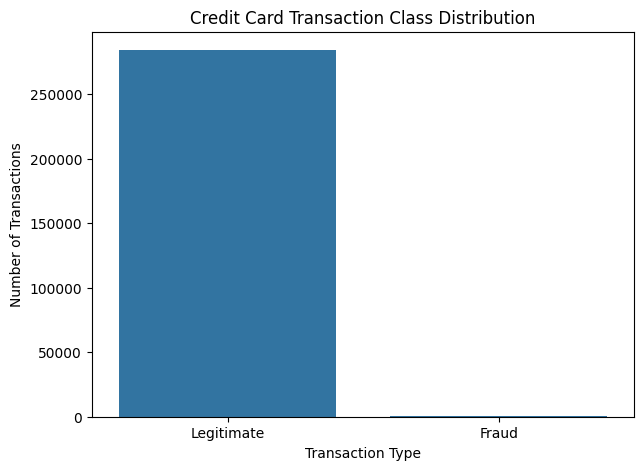

In [12]:
class_plot = (
    df["Class"]
    .map({
        0: "Legitimate",
        1: "Fraud"
    })
)

plt.figure(figsize=(7, 5))

sns.countplot(
    x=class_plot
)

plt.title("Credit Card Transaction Class Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

## Class Imbalance Observation

The dataset is extremely imbalanced because legitimate transactions significantly outnumber fraudulent transactions. This creates a challenge for machine learning models because a model may become biased toward the majority class. As a result, a model could achieve very high overall accuracy while still failing to identify many fraudulent transactions. Therefore, metrics such as Precision, Recall, and F1-score are particularly important for evaluating fraud detection performance.

## Feature and Target Selection

The `Class` column is the target variable. All remaining columns are used as input features.

In [13]:
X = df.drop("Class", axis=1)

y = df["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (284807, 30)
Target shape: (284807,)


## Train-Test Split

The dataset is divided into training and testing sets using an 80/20 split.

Stratification is used to preserve approximately the same fraud ratio in both datasets.

Importantly, SMOTE will only be applied to the training data. The test set remains untouched so that the model is evaluated on realistic, unseen data.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (227845, 30)
Testing set: (56962, 30)


In [15]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [16]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()

X_train_scaled[
    ["Time", "Amount"]
] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_test_scaled[
    ["Time", "Amount"]
] = scaler.transform(
    X_test[["Time", "Amount"]]
)

print("Scaling completed successfully.")

Scaling completed successfully.


## Baseline Logistic Regression

A Logistic Regression model is first trained on the original imbalanced training dataset. This provides a baseline that can later be compared with the SMOTE-balanced model.

In [18]:
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(
    X_train_scaled,
    y_train
)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [19]:
baseline_predictions = baseline_model.predict(
    X_test_scaled
)

In [20]:
baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions
)

print(f"Accuracy:  {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall:    {baseline_recall:.4f}")
print(f"F1-score:  {baseline_f1:.4f}")

Accuracy:  0.9992
Precision: 0.8289
Recall:    0.6429
F1-score:  0.7241


In [21]:
print("Baseline Classification Report:\n")

print(
    classification_report(
        y_test,
        baseline_predictions,
        target_names=[
            "Legitimate",
            "Fraud"
        ]
    )
)

Baseline Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



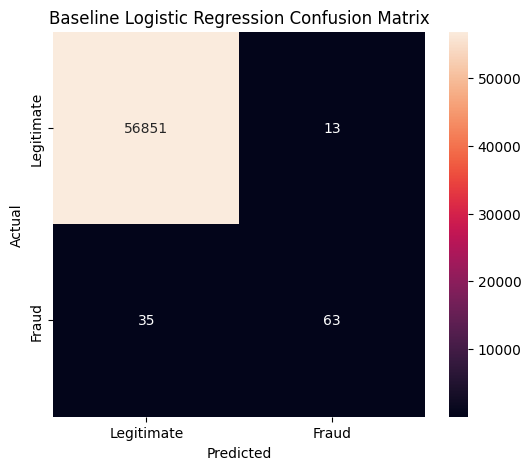

In [22]:
baseline_cm = confusion_matrix(
    y_test,
    baseline_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    baseline_cm,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Baseline Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Handling Imbalance with SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) addresses class imbalance by generating synthetic examples of the minority class.

SMOTE is applied only to the training data. Applying SMOTE before the train-test split would introduce synthetic information into the evaluation process and could cause data leakage.smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("SMOTE applied successfully.")

In [23]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("SMOTE applied successfully.")

SMOTE applied successfully.


In [24]:
print("BEFORE SMOTE")
print("-" * 30)

print(y_train.value_counts())

print("\nAFTER SMOTE")
print("-" * 30)

print(y_train_smote.value_counts())

BEFORE SMOTE
------------------------------
Class
0    227451
1       394
Name: count, dtype: int64

AFTER SMOTE
------------------------------
Class
0    227451
1    227451
Name: count, dtype: int64


In [25]:
before_counts = y_train.value_counts().sort_index()
after_counts = y_train_smote.value_counts().sort_index()

balance_comparison = pd.DataFrame({
    "Before SMOTE": before_counts,
    "After SMOTE": after_counts
})

balance_comparison.index = [
    "Legitimate",
    "Fraud"
]

balance_comparison

,Before SMOTE,After SMOTE
Legitimate,227451,227451
Fraud,394,227451


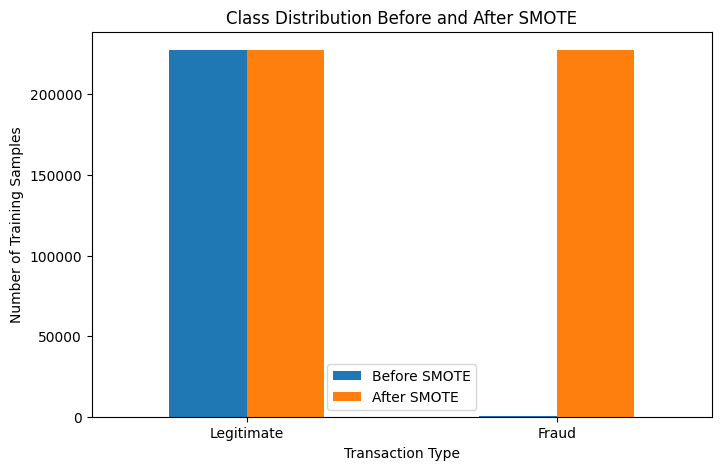

In [26]:
balance_comparison.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Class Distribution Before and After SMOTE")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Training Samples")
plt.xticks(rotation=0)

plt.show()

## Logistic Regression After SMOTE

The same Logistic Regression algorithm is retrained using the SMOTE-balanced training dataset. Using the same algorithm allows a fair comparison of how balancing the training data affects model performance.

In [27]:
smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_model.fit(
    X_train_smote,
    y_train_smote
)

print("SMOTE model trained successfully.")

SMOTE model trained successfully.


In [28]:
smote_predictions = smote_model.predict(
    X_test_scaled
)

In [29]:
smote_accuracy = accuracy_score(
    y_test,
    smote_predictions
)

smote_precision = precision_score(
    y_test,
    smote_predictions
)

smote_recall = recall_score(
    y_test,
    smote_predictions
)

smote_f1 = f1_score(
    y_test,
    smote_predictions
)

print(f"Accuracy:  {smote_accuracy:.4f}")
print(f"Precision: {smote_precision:.4f}")
print(f"Recall:    {smote_recall:.4f}")
print(f"F1-score:  {smote_f1:.4f}")

Accuracy:  0.9742
Precision: 0.0580
Recall:    0.9184
F1-score:  0.1092


In [30]:
print("SMOTE Model Classification Report:\n")

print(
    classification_report(
        y_test,
        smote_predictions,
        target_names=[
            "Legitimate",
            "Fraud"
        ]
    )
)

SMOTE Model Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



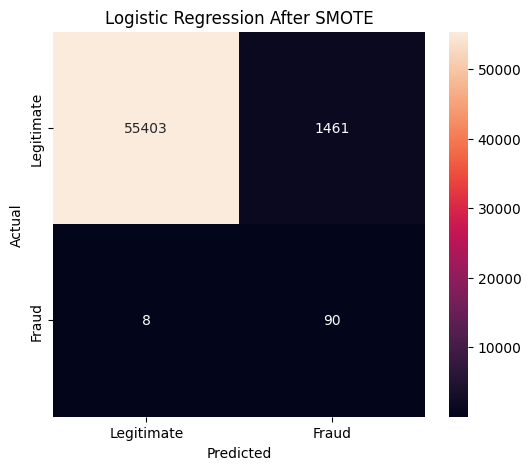

In [31]:
smote_cm = confusion_matrix(
    y_test,
    smote_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    smote_cm,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Logistic Regression After SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Performance Comparison

The baseline and SMOTE-balanced models are compared using Accuracy, Precision, Recall, and F1-score.

For fraud detection, Recall is especially important because it measures how many actual fraudulent transactions the model successfully identifies.

In [32]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Before SMOTE": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    "After SMOTE": [
        smote_accuracy,
        smote_precision,
        smote_recall,
        smote_f1
    ]
})

comparison[
    ["Before SMOTE", "After SMOTE"]
] = comparison[
    ["Before SMOTE", "After SMOTE"]
].round(4)

comparison

,Metric,Before SMOTE,After SMOTE
0,Accuracy,0.9992,0.9742
1,Precision,0.8289,0.0580
2,Recall,0.6429,0.9184
3,F1-score,0.7241,0.1092


In [33]:
print(
    f"Precision Change: "
    f"{smote_precision - baseline_precision:+.4f}"
)

print(
    f"Recall Change: "
    f"{smote_recall - baseline_recall:+.4f}"
)

print(
    f"F1-score Change: "
    f"{smote_f1 - baseline_f1:+.4f}"
)

Precision Change: -0.7709
Recall Change: +0.2755
F1-score Change: -0.6150


## Why Accuracy Is Misleading for Fraud Detection

Accuracy can be misleading for this dataset because fraudulent transactions represent only a tiny percentage of all transactions. A model could predict almost every transaction as legitimate and still achieve extremely high accuracy simply because the majority class dominates the dataset. However, such a model would be ineffective because it could miss many actual fraud cases. Therefore, Precision, Recall, and F1-score provide a more meaningful evaluation of fraud detection performance, with Recall being particularly important when the cost of missing fraud is high.

## Understanding the Evaluation Metrics

**Precision:** Of all transactions predicted as fraud, how many were actually fraudulent?

**Recall:** Of all actual fraudulent transactions, how many did the model successfully detect?

**F1-score:** Provides a balance between Precision and Recall.

In fraud detection, high Recall is valuable because false negatives represent fraudulent transactions that the system failed to detect. However, Precision also matters because too many false fraud alerts can create unnecessary investigation costs.

In [34]:
print("FINAL COMPARISON")
print("=" * 45)

print(
    f"Baseline Precision : {baseline_precision:.4f}"
)

print(
    f"SMOTE Precision    : {smote_precision:.4f}"
)

print()

print(
    f"Baseline Recall    : {baseline_recall:.4f}"
)

print(
    f"SMOTE Recall       : {smote_recall:.4f}"
)

print()

print(
    f"Baseline F1-score  : {baseline_f1:.4f}"
)

print(
    f"SMOTE F1-score     : {smote_f1:.4f}"
)

FINAL COMPARISON
Baseline Precision : 0.8289
SMOTE Precision    : 0.0580

Baseline Recall    : 0.6429
SMOTE Recall       : 0.9184

Baseline F1-score  : 0.7241
SMOTE F1-score     : 0.1092


## Conclusion

This project demonstrated the impact of class imbalance on a real-world fraud detection problem. The original dataset contained significantly more legitimate transactions than fraudulent transactions, making accuracy alone an unreliable measure of model quality.

A baseline Logistic Regression model was first trained using the original imbalanced training data. SMOTE was then applied only to the training set to generate synthetic minority-class samples, after which the same model was retrained.

The before-and-after comparison demonstrates how balancing the training data affects Precision, Recall, and F1-score. This experiment highlights the importance of selecting evaluation metrics and imbalance-handling techniques based on the real-world objective of the machine learning system.